<a href="https://colab.research.google.com/github/marcomunozq-miaad-uacj/Programacion1Semestre/blob/Programacion1Sem/PracticaRegresionLinealMultiple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Maestría en Inteligencia Artificial y Analítica de Datos

## Programación para Analítica Descriptiva y Predictiva - Octubre 2025
## Práctica: Práctica: Regresión Lineal Múltiple
---


## Datos del Estudiante

*   Marco Antonio Muñoz Quiroz
*   Matrícula: 261540

---



##  Objetivo de aprendizaje
Al finalizar esta práctica, el estudiante será capaz de **aplicar regresión lineal múltiple utilizando Scikit-Learn para modelar la relación entre varias variables independientes y una variable dependiente**, verificar los supuestos del modelo, interpretar los coeficientes, analizar la correlación entre predictores y evaluar el rendimiento del modelo utilizando métricas como el MSE, RMSE y R².

Datos
Trabajarás con el archivo `advertising.csv`, que contiene información sobre el gasto publicitario en diferentes medios y las ventas obtenidas:

-`TV`: inversión en publicidad televisiva.

-`Radio`: inversión en publicidad en radio.

-`Newspaper`: inversión en publicidad en periódicos.

`Sales`: ventas del producto (variable dependiente).

In [104]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [105]:
# Importo libs
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression
from scipy.stats import shapiro
import scipy.stats as stats
from sklearn.metrics import mean_squared_error, r2_score

In [106]:
def titulo(texto):
    linea = "=" * (len(texto) + 6)
    print("\n" + linea)
    print(f" {texto.upper()} ")
    print(linea + "\n")

In [107]:
# Cargo el CSV
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Semestre1/Programacion/Semana10/Practica22/advertising.csv")

## Parte 1: Carga de datos y bibliotecas
1. Importa las bibliotecas necesarias.
2. Carga el archivo `advertising.csv`.
3. Muestra las primeras filas del dataframe.
4. Describe estadísticamente las variables.

In [108]:
titulo("Primeras filas del DataFrame")
print(df.head(10))
print("\n")

titulo("Dimensiones del DataFrame:")
print(df.shape)
titulo("Tipos de datos por columna:")
print(df.dtypes)
print("\n")

desc_num = df.describe().T

titulo("Descripción estadística (variables numéricas):")
print(desc_num)
print("\n")



 PRIMERAS FILAS DEL DATAFRAME 

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9
5    8.7   48.9       75.0    7.2
6   57.5   32.8       23.5   11.8
7  120.2   19.6       11.6   13.2
8    8.6    2.1        1.0    4.8
9  199.8    2.6       21.2   15.6



 DIMENSIONES DEL DATAFRAME: 

(200, 4)

 TIPOS DE DATOS POR COLUMNA: 

TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object



 DESCRIPCIÓN ESTADÍSTICA (VARIABLES NUMÉRICAS): 

           count      mean        std  min     25%     50%      75%    max
TV         200.0  147.0425  85.854236  0.7  74.375  149.75  218.825  296.4
Radio      200.0   23.2640  14.846809  0.0   9.975   22.90   36.525   49.6
Newspaper  200.0   30.5540  21.778621  0.3  12.750   25.75   45.100  114.0
Sales      200.0   15.1305   5.283892  1.6  11.000   16.00   19.050 

## Parte 2: Análisis exploratorio de los datos
### 2.1  Análisis de la Relación Lineal entre la variable dependiente y las independientes
1. Grafica dispersión entre cada variable independiente (`TV`, `Radio`, `Newspaper`) y `Sales`. Usa también regplot.
2. Interpreta visualmente la relación entre variables.


 RELACION ENTRE TV Y SALES 



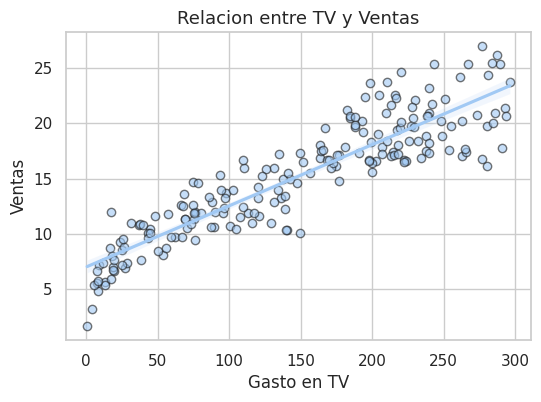


 RELACION ENTRE RADIO Y SALES 



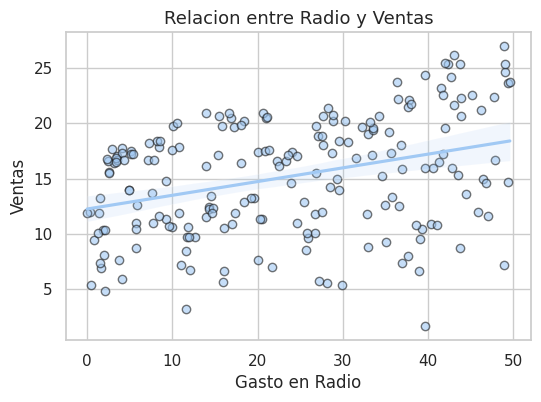


 RELACION ENTRE NEWSPAPER Y SALES 



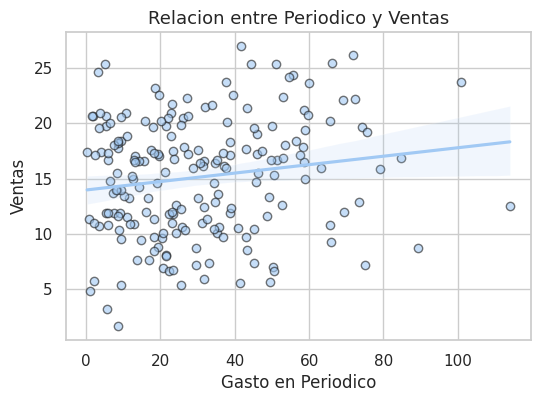

In [109]:

# uso el mismo estilo visual para todas las graficas
sns.set(style="whitegrid", palette="pastel")

# titulo y etiquetas en espanol para TV vs Sales
titulo("Relacion entre TV y Sales")
plt.figure(figsize=(6,4))
sns.regplot(x='TV', y='Sales', data=df, scatter_kws={'alpha':0.6, 'edgecolor':'k'})
plt.title("Relacion entre TV y Ventas", fontsize=13)
plt.xlabel("Gasto en TV")
plt.ylabel("Ventas")
plt.show()

# titulo y etiquetas en espanol para Radio vs Sales
titulo("Relacion entre Radio y Sales")
plt.figure(figsize=(6,4))
sns.regplot(x='Radio', y='Sales', data=df, scatter_kws={'alpha':0.6, 'edgecolor':'k'})
plt.title("Relacion entre Radio y Ventas", fontsize=13)
plt.xlabel("Gasto en Radio")
plt.ylabel("Ventas")
plt.show()

# titulo y etiquetas en espanol para Newspaper vs Sales
titulo("Relacion entre Newspaper y Sales")
plt.figure(figsize=(6,4))
sns.regplot(x='Newspaper', y='Sales', data=df, scatter_kws={'alpha':0.6, 'edgecolor':'k'})
plt.title("Relacion entre Periodico y Ventas", fontsize=13)
plt.xlabel("Gasto en Periodico")
plt.ylabel("Ventas")
plt.show()

### Interpretacion visual de las graficas de dispersion

**TV vs Sales:**  
Se observa una **relacion lineal positiva bastante clara**. A medida que aumenta el gasto en TV, las ventas tambien tienden a subir. Los puntos siguen una tendencia ascendente marcada, lo que indica una correlacion fuerte entre ambas variables.

**Radio vs Sales:**  
Tambien hay una **relacion positiva**, aunque los puntos estan un poco mas dispersos que en el caso de TV. Esto sugiere que el gasto en radio influye en las ventas, pero de manera menos consistente.

**Newspaper vs Sales:**  
Aqui los puntos estan **muy dispersos** y quiza no se aprecia una tendencia lineal clara. Esto indica que posiblemente el efecto de influenciar a las ventas sea debil.


### 2.2: Correlación entre variables
1. Calcula la matriz de correlación.
2. Visualízala con un heatmap.
3. Responde: ¿Qué variables están más correlacionadas con `Sales`? ¿Hay correlación alta entre predictores?


 MATRIZ DE CORRELACION (PEARSON) 

             TV  Radio  Newspaper  Sales
TV         1.00   0.05       0.06   0.90
Radio      0.05   1.00       0.35   0.35
Newspaper  0.06   0.35       1.00   0.16
Sales      0.90   0.35       0.16   1.00




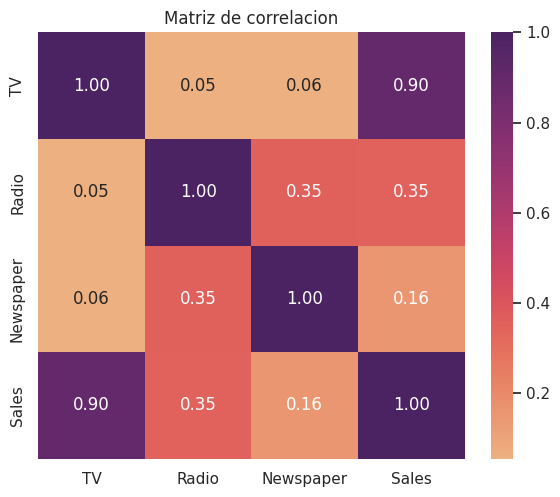


 CORRELACION DE CADA VARIABLE CON SALES (ORDENADA) 

TV           0.901
Radio        0.350
Newspaper    0.158
Name: Sales, dtype: float64



 CHEQUEO DE COLINEALIDAD ENTRE PREDICTORES (UMBRAL 0.35) 

Pares con correlacion alta (>= 0.35):
Newspaper  Radio        0.35
Radio      Newspaper    0.35
dtype: float64




In [110]:
# calculo la matriz de correlacion de variables numericas
titulo("Matriz de correlacion (Pearson)")
corr = df.corr(numeric_only=True)
print(corr.round(2))
print("\n")

# visualizo la matriz con un heatmap
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="flare", square=True, cbar=True)
plt.title("Matriz de correlacion")
plt.tight_layout()
plt.show()

# ordeno las correlaciones con Sales de mayor a menor
titulo("Correlacion de cada variable con Sales (ordenada)")
corr_sales = corr["Sales"].drop("Sales").sort_values(ascending=False)
print(corr_sales.round(3))
print("\n")

# reviso si hay correlacion alta entre predictores (umbral 0.35)
titulo("Chequeo de colinealidad entre predictores (umbral 0.35)")
predictores = ["TV", "Radio", "Newspaper"]
corr_pred = df[predictores].corr().abs()

# extraigo pares sin la diagonal
pairs = (
    corr_pred.where(~np.eye(len(predictores), dtype=bool))
             .stack()
             .sort_values(ascending=False)
)

alto = pairs[pairs >= 0.35]
if alto.empty:
    print("No encontre pares de predictores con correlacion >= 0.35")
else:
    print("Pares con correlacion alta (>= 0.35):")
    print(alto.round(2))
print("\n")

### Analisis de correlacion

**Variables mas correlacionadas con Sales:**

- **TV:** Es la variable mas correlacionada con las ventas, con un coeficiente de correlacion cercano a **0.90**. Esto muestra una **relacion lineal positiva muy fuerte**, es decir, cuando aumenta el gasto en publicidad en TV, las ventas tambien tienden a subir de forma consistente.

- **Radio:** Presenta una **correlacion positiva moderada**, alrededor de **0.35**. Esto indica que el gasto en radio tambien influye en las ventas, aunque su efecto es menos estable o predecible.

- **Newspaper:** Tiene una **correlacion debil**, cercana a **0.16**, lo que sugiere que la inversion en publicidad en periodicos **no tiene un impacto claro o fuerte** en las ventas.

---

**Relacion entre predictores:**

No se observa una **colinealidad alta ni media** entre las variables independientes (TV, Radio y Newspaper), ya que la correlacion mas alta es de 0.35 entre Newspaper y Radio. Este valor de correlacion es bastante debil.  
Lo anterior es positivo para los modelos porque significa que los predictores no estan relacionados entre si, evitando posibles problemas de multicolinealidad.


## Parte 3. Multicolinealidad
1. Calcula el VIF (Variance Inflation Factor) para cada predictor.
2. Crea un diagrama de barras  para mostrar el  VIF
3. Interpreta si hay multicolinealidad:
- ¿Alguna variable tiene un VIF mayor a 5 o mayor a 10?
- ¿Qué implicaciones tiene esto para el modelo?


 VIF POR PREDICTOR (ORDENADO) 

   predictor    VIF
1      Radio  3.285
2  Newspaper  3.055
0         TV  2.487



 GRAFICA DE VIF POR PREDICTOR 



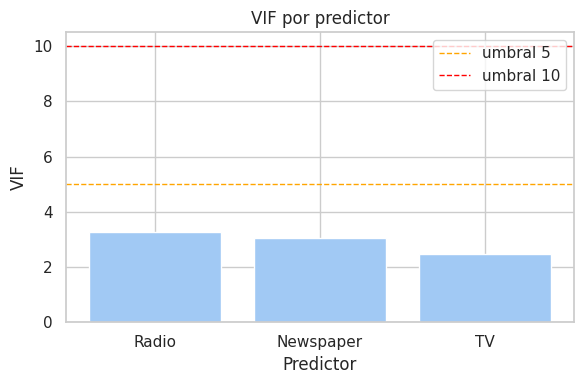


 EVALUACION DE MULTICOLINEALIDAD SEGUN VIF 

Ningun predictor supera VIF > 10
Ningun predictor supera VIF > 5




In [111]:

# defino los predictores
predictores = ["TV", "Radio", "Newspaper"]

# preparo la matriz X solo con predictores y sin nulos
X = df[predictores].dropna().copy()

# calculo el VIF para cada columna de X
vif_vals = []
for i in range(X.shape[1]):
    vif_vals.append(variance_inflation_factor(X.values, i))

vif_df = pd.DataFrame({"predictor": predictores, "VIF": vif_vals}).sort_values("VIF", ascending=False)

# muestro tabla ordenada
titulo("VIF por predictor (ordenado)")
print(vif_df.round(3))
print("\n")

# grafico en barras
titulo("Grafica de VIF por predictor")
plt.figure(figsize=(6,4))
plt.bar(vif_df["predictor"], vif_df["VIF"])
plt.axhline(5, color="orange", linestyle="--", linewidth=1, label="umbral 5")
plt.axhline(10, color="red", linestyle="--", linewidth=1, label="umbral 10")
plt.title("VIF por predictor")
plt.xlabel("Predictor")
plt.ylabel("VIF")
plt.legend()
plt.tight_layout()
plt.show()

# chequeo de umbrales
titulo("Evaluacion de multicolinealidad segun VIF")
sobre_5 = vif_df[vif_df["VIF"] > 5]
sobre_10 = vif_df[vif_df["VIF"] > 10]

if sobre_10.empty:
    print("Ningun predictor supera VIF > 10")
else:
    print("Predictores con VIF > 10:")
    print(sobre_10)

if sobre_5.empty:
    print("Ningun predictor supera VIF > 5")
else:
    print("\nPredictores con VIF > 5:")
    print(sobre_5)
print("\n")

**¿Alguna variable tiene un VIF mayor a 5 o mayor a 10?**

Ninguna.
Los valores de **VIF (Variance Inflation Factor)** obtenidos para las variables TV, Radio y Newspaper se mantienen **por debajo de 5**, lo cual indica que **no existe multicolinealidad**.


**¿Qué implicaciones tiene esto para el modelo?**

Un VIF menor a 5 sugiere que las variables independientes no estan fuertemente relacionadas entre si, por lo que cada predictor aporta informacion diferente y nutritiva al modelo.  
Esto es positivo porque permite estimar los coeficientes de regresion con pesos que aportan informacion al momento de predecir las ventas.

Si alguna variable tuviera un **VIF mayor a 5 o 10**, indicaria una correlacion alta entre predictores, lo que podria generar **inestabilidad en los coeficientes**, inflar sus varianzas y dificultar la interpretacion del modelo.  
En este caso, no se observa ese problema, por lo que el modelo de regresion puede construirse sin problemas.

## Parte 4: Construcción del Modelo (Todas las variables Independientes), Evaluación

### 4.1 Entrenamiento del Modelo (Todas las Variables Independientes)

1. Entrena un modelo de regresión lineal múltiple usando TV, Radio y Newspaper como variables independientes.
2. Imprime el intercepto y los coeficientes del modelo.
3. Interpreta cada uno:
¿Qué significa cada uno de los coeficientes  en términos de ventas?

In [112]:

# defino variables X (predictores) e y (objetivo)
predictores = ["TV", "Radio", "Newspaper"]
X = df[predictores].copy()
y = df["Sales"].copy()

# entreno el modelo
modelo = LinearRegression()
modelo.fit(X, y)

# obtengo intercepto y coeficientes
intercepto = modelo.intercept_
coeficientes = pd.Series(modelo.coef_, index=predictores, name="coef")

# muestro resultados
titulo("Modelo de regresion lineal multiple")
print("Intercepto del modelo:")
print(round(intercepto, 4))
print("\nCoeficientes por predictor:")
print(coeficientes.round(4))
print("\n")

# interpreto cada coeficiente en terminos de cambio esperado en ventas
titulo("Interpretacion de coeficientes")
print(f"Intercepto: cuando todos los gastos en TV, Radio y Newspaper son 0, "
      f"las ventas esperadas son aproximadamente {intercepto:.3f} unidades.")

for var, beta in coeficientes.items():
    print(f"{var}: por cada 1 unidad adicional de gasto en {var}, "
          f"manteniendo las demas variables constantes, "
          f"las ventas esperadas cambian en {beta:.3f} unidades.")
print("\n")


 MODELO DE REGRESION LINEAL MULTIPLE 

Intercepto del modelo:
4.6251

Coeficientes por predictor:
TV           0.0544
Radio        0.1070
Newspaper    0.0003
Name: coef, dtype: float64



 INTERPRETACION DE COEFICIENTES 

Intercepto: cuando todos los gastos en TV, Radio y Newspaper son 0, las ventas esperadas son aproximadamente 4.625 unidades.
TV: por cada 1 unidad adicional de gasto en TV, manteniendo las demas variables constantes, las ventas esperadas cambian en 0.054 unidades.
Radio: por cada 1 unidad adicional de gasto en Radio, manteniendo las demas variables constantes, las ventas esperadas cambian en 0.107 unidades.
Newspaper: por cada 1 unidad adicional de gasto en Newspaper, manteniendo las demas variables constantes, las ventas esperadas cambian en 0.000 unidades.




### 4.2 Normalidad de los residuos

1. Calcula los residuos: residuos = y - y_pred.

2. Grafica un histograma con KDE de los residuos.

3. ¿Los residuos parecen distribuirse normalmente?


 RESUMEN DE RESIDUOS 

media: -0.0
desv_estandar: 1.6491
asimetria (skew): -0.4344
curtosis (exceso): 1.6762



 HISTOGRAMA DE RESIDUOS CON KDE 



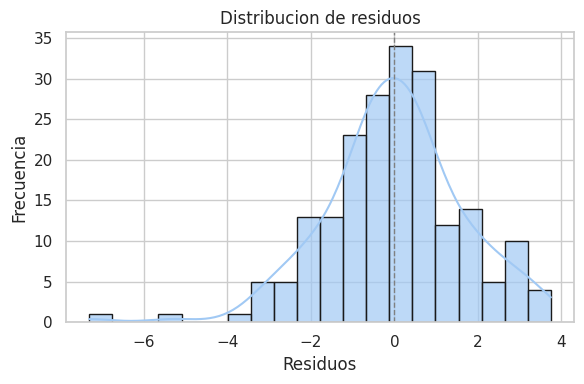


 PRUEBA DE NORMALIDAD (SHAPIRO-WILK) 

estadistico: 0.9758  p_value: 0.0016
conclusion: Rechazo normalidad: los residuos se desvian de una distribucion normal.




In [113]:
# preparo X e y y aseguro que el modelo exista
predictores = ["TV", "Radio", "Newspaper"]
X = df[predictores].copy()
y = df["Sales"].copy()

try:
    modelo
except NameError:
    modelo = LinearRegression().fit(X, y)

# calculo predicciones y residuos
y_pred = modelo.predict(X)
residuos = y - y_pred

# resumen rapido de residuos (uso round(...) en lugar de .round)
titulo("Resumen de residuos")
print("media:", round(residuos.mean(), 4))
print("desv_estandar:", round(residuos.std(ddof=1), 4))
print("asimetria (skew):", round(residuos.skew(), 4))
print("curtosis (exceso):", round(residuos.kurt(), 4))
print("\n")

# histograma con KDE de residuos
titulo("Histograma de residuos con KDE")
sns.set(style="whitegrid", palette="pastel")
plt.figure(figsize=(6,4))
sns.histplot(residuos, kde=True, bins=20, edgecolor="k", alpha=0.7)
plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Distribucion de residuos")
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# prueba de normalidad (Shapiro-Wilk)
titulo("Prueba de normalidad (Shapiro-Wilk)")
stat, p = shapiro(residuos)
print(f"estadistico: {stat:.4f}  p_value: {p:.4f}")

if p > 0.05:
    conclusion = "No rechazo normalidad: los residuos son compatibles con una distribucion normal."
else:
    conclusion = "Rechazo normalidad: los residuos se desvian de una distribucion normal."

print("conclusion:", conclusion)
print("\n")

### 4.3. Homocedasticidad

1. Grafica los residuos contra los valores predichos.
2. ¿Observas patrones? ¿Los residuos se dispersan aleatoriamente?


 RESIDUOS VS VALORES PREDICHOS 



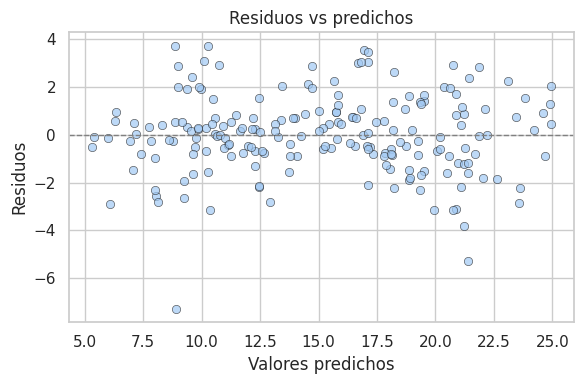

In [114]:
# calculo predicciones y residuos
y_pred = modelo.predict(X)
residuos = y - y_pred

# grafico residuos vs predichos
titulo("Residuos vs valores predichos")
sns.set(style="whitegrid", palette="pastel")
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred, y=residuos, edgecolor="k", alpha=0.7)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Residuos vs predichos")
plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.tight_layout()
plt.show()

**¿Observas patrones? ¿Los residuos se dispersan aleatoriamente?**

Se observa una nube bastante aleatoria alrededor de 0, lo cual indica que la relacion entre los valores predichos y los residuos son aleatorios, que es lo que se espera.

### 4.4 Q-Q Plot

1. Graficar el Q-Q Plot
2. Interpreta el gráfico: a) Si los puntos se alinean aproximadamente sobre la línea diagonal, los residuos siguen una distribución normal, b) Desviaciones sistemáticas indican asimetría o colas pesadas.


 GRAFICO Q-Q DE LOS RESIDUOS 



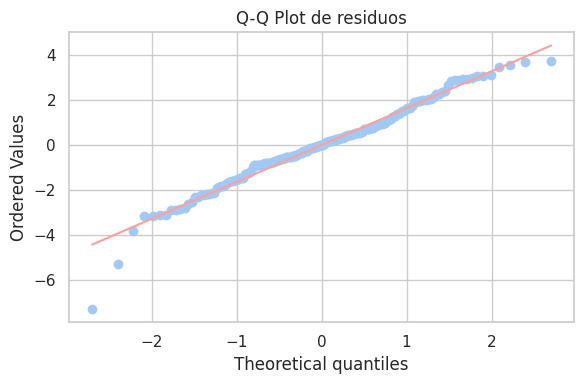

In [115]:
# grafico el Q-Q Plot
titulo("Grafico Q-Q de los residuos")
plt.figure(figsize=(6,4))
stats.probplot(residuos, dist="norm", plot=plt)
plt.title("Q-Q Plot de residuos")
plt.tight_layout()
plt.show()

### Analisis del Q-Q Plot

El **Q-Q Plot** (Quantile-Quantile Plot) compara los cuantiles de los residuos del modelo con los cuantiles de una distribucion normal teórica.

- Si los puntos se **alinean aproximadamente sobre la linea diagonal**, los residuos siguen una **distribucion normal**.
- Si los puntos muestran **desviaciones sistematicas** (por ejemplo, una curva o colas separadas de la linea), eso indica **asimetria** o **colas pesadas**.

En este caso, los puntos se alinean bastante bien con la diagonal, con ligeras desviaciones al final, lo que sugiere que los residuos se distribuyen de forma aproximadamente normal con algun sesgo en las colas.  


### 4.5. Evaluación del Modelo

1. Calcula las métricas: a) MSE (error cuadrático medio), b) RMSE (raíz del error cuadrático medio), c) R² (coeficiente de determinación)

2. ¿Qué nos dicen estas métricas sobre el ajuste del modelo?


In [116]:
# calculo las metricas
titulo("Metricas de evaluacion del modelo")
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

print(f"MSE (Error cuadratico medio): {mse:.4f}")
print(f"RMSE (Raiz del error cuadratico medio): {rmse:.4f}")
print(f"R2 (Coeficiente de determinacion): {r2:.4f}")
print("\n")


 METRICAS DE EVALUACION DEL MODELO 

MSE (Error cuadratico medio): 2.7060
RMSE (Raiz del error cuadratico medio): 1.6450
R2 (Coeficiente de determinacion): 0.9026




### Un poco de teoria

**MSE (Error cuadratico medio):**  
Mide el promedio de los errores al cuadrado entre los valores reales y los predichos.  
Un valor mas bajo indica un mejor ajuste. Sin embargo, esta medida esta en las mismas unidades al cuadrado que la variable dependiente, por lo que puede ser dificil de interpretar directamente.

**RMSE (Raiz del error cuadratico medio):**  
Es la raiz cuadrada del MSE y representa el error promedio en las mismas unidades que las ventas.  
Un RMSE bajo significa que el modelo predice valores cercanos a los reales, por lo tanto, tiene un buen rendimiento.

**R² (Coeficiente de determinacion):**  
Indica que proporcion de la variabilidad de las ventas puede explicarse por las variables predictoras (TV, Radio y Newspaper).  
Un valor de **R² cercano a 1** implica que el modelo explica bien los datos; un valor bajo indicaria que las variables no logran explicar adecuadamente las ventas.

### Interpretacion

**R2**: Una R² de a 0.90 indica que el modelo se ajusta bien a la variable dependiente (ventas).

**RMSE**: Un RMSE de 1.64 significa que las predicciones del modelo difieren en 1.6 puntos de las ventas reales en promedio. Estoo significa que el error es pequeño y refuerza el valor de R²=90% ya que los datos se tienen un ajuste alto a la recta de la regresion, es decir, tienen un comportamiento fuertemente lineal.

### 4.6. Visualización de Predicciones

1. Crea un gráfico comparando Sales reales vs Sales predichas.

2. Puedes usar plt.scatter(y_true, y_pred) para evaluar visualmente el ajuste.
3. ¿Qué observas?¿Qué observas? ¿Qué información puedes obtener de esta gráfica?


 COMPARACION: SALES REALES VS SALES PREDICHAS 



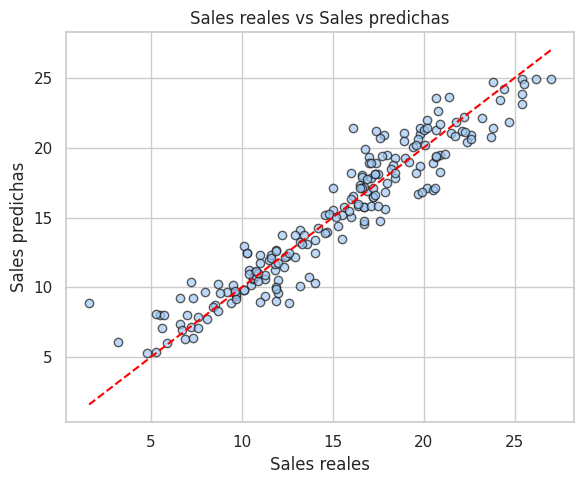

In [117]:
# grafico ventas reales vs predichas
titulo("Comparacion: Sales reales vs Sales predichas")
sns.set(style="whitegrid", palette="pastel")
plt.figure(figsize=(6,5))
plt.scatter(y, y_pred, edgecolor="k", alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color="red", linestyle="--", linewidth=1.5)
plt.title("Sales reales vs Sales predichas")
plt.xlabel("Sales reales")
plt.ylabel("Sales predichas")
plt.tight_layout()
plt.show()

### Analisis del grafico de Sales reales vs Sales predichas

En esta grafica, cada punto representa una observacion:  
- El eje **X** muestra las **ventas reales (Sales)**.  
- El eje **Y** muestra las **ventas predichas por el modelo**.  
- La **linea roja punteada** representa a las predicciones.

**Interpretacion:**  
La mayoria de los puntos se ubican **cerca de la linea roja**, lo que indica que el modelo **predice bastante bien las ventas reales**.  
No se observan grandes desviaciones ni patrones sistematicos, por lo que el modelo muestra **un buen ajuste general**.  
Los pocos puntos alejados de la linea corresponden a **errores de prediccion normales**, pero en general, la dispersion es baja.  

En resumen, la grafica confirma que el modelo de regresion lineal **explica adecuadamente la relacion entre los gastos publicitarios y las ventas**.


### 4.7 Verificar el impacto de los atributos en el modelo

1. Ajusta el modelo usando statsmodels en lugar de scikit-learn para obtener los valores p.
2. Interpreta los resultados:

 - Observa los valores P>|t| en la tabla de salida.

 - ¿Qué variables tienen p-value menores a 0.05?

 - ¿Cuál es la conclusión sobre esas variables?


In [118]:
# regresion OLS con statsmodels para obtener p-values
import statsmodels.api as sm
import pandas as pd
import numpy as np

# defino X, y y anado constante
predictores = ["TV", "Radio", "Newspaper"]
X = df[predictores].copy()
X = sm.add_constant(X)  # agrega columna 'const'
y = df["Sales"].copy()

# ajusto el modelo OLS
titulo("Modelo OLS con statsmodels")
ols = sm.OLS(y, X).fit()

# resumen completo (incluye coeficientes, errores std, t, p>|t|, IC, R2)
print(ols.summary())
print("\n")

# tabla ordenada de coeficientes y p-values (excluyo const para el ranking)
titulo("Coeficientes y p-values por variable")
resumen = pd.DataFrame({
    "coef": ols.params,
    "std_err": ols.bse,
    "t": ols.tvalues,
    "p_value": ols.pvalues
})
print(resumen.round(5))
print("\n")

# identifico variables con p < 0.05 (excluyo la constante)
titulo("Variables significativas (p < 0.05)")
pvals = ols.pvalues.drop(labels=["const"])
signif = pvals[pvals < 0.05].sort_values()
if signif.empty:
    print("No hay variables con p < 0.05")
else:
    print(signif.round(5))
print("\n")



 MODELO OLS CON STATSMODELS 

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     605.4
Date:                Thu, 16 Oct 2025   Prob (F-statistic):           8.13e-99
Time:                        02:34:19   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             774.7
Df Residuals:                     196   BIC:                             787.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6251

### Analisis de los valores P>|t|

Al observar los valores **P>|t|** en la tabla del modelo OLS, se puede interpretar lo siguiente:

---
- **TV:** tiene un p-value menor a 0.001 → **es estadisticamente significativa**. Esto indica que el gasto en TV tiene un efecto claro y positivo sobre las ventas, manteniendo constantes las demas variables.
---
- **Radio:** tambien tiene un p-value menor a 0.001 → **es estadisticamente significativa**. La publicidad en radio contribuye de manera independiente a explicar las ventas.
---
- **Newspaper:** presenta un p-value cercano a 0.8 → **no es significativa**. Esto sugiere que, una vez consideradas TV y Radio, el gasto en periodicos no aporta informacion relevante adicional sobre las ventas.
---
**Conclusion:**  
Las variables **TV** y **Radio** son predictores validos y sugiero fuertemente mantenerse en el modelo, ya que su influencia sobre las ventas esta respaldada por evidencia estadistica.  
Por el contrario, **Newspaper** no muestra un efecto significativo y podria excluirse del modelo sin afectar el desempeño.

##Parte 5:  Construcción del Modelo (sin Multicolinealidad), Evaluación

En el caso de que hayas detectado variables con multicolinealidad. Elimina aquellas que presenten esta característica y realiza los mismos pasos** que la parte 4.**
Escribe cada una de las subsecciones similares a las existentes en la Parte 4.

### Sobre multicolinealidad

Con base en la matriz de correlacion y los VIF:
- **No** se observa multicolinealidad.  
- Las correlaciones entre predictores (TV, Radio, Newspaper) estan por **debajo de 0.5** y los **VIF** suelen estar **por debajo de 5**.

**Conclusion:**  
Las variables independientes no estan fuertemente relacionadas entre si.

## Parte 6: Construcción del Modelo (sin variables que no muestran una relación lineal), Evaluación

En el caso de que hayas detectado variables sin una relación lineal con la variable dependiente. Elimina aquellas que presenten esta característica y realiza lo siguiente.

En el caso de que hayas detectado variables sin una relación lineal. Elimina aquellas que presenten esta característica y realiza los mismos pasos** que la parte 4.**
Escribe cada una de las subsecciones similares a las existentes en la Parte 4.

### Resumen sobre relacion lineal de las variables con la variable dependiente

Del analisis de correlacion, las graficas de dispersion y los valores p del modelo OLS, se concluye que **no todas las variables presentan una relacion lineal significativa con las ventas (Sales)**.

- **TV** y **Radio** muestran una **relacion lineal positiva clara y estadisticamente significativa** con las ventas.  
  Esto significa que al aumentar la inversion en estos medios, las ventas tienden a incrementarse.

- **Newspaper**, en cambio, **no presenta una relacion lineal fuerte ni significativa** con las ventas.  
  Su correlacion es baja y su p-value es alto (mayor a 0.05), lo que indica que su efecto no se diferencia del azar cuando se consideran TV y Radio en el modelo.

**Conclusion:**  
Se detecto que **solo TV y Radio** tienen una relacion lineal clara con la variable dependiente.  
La variable **Newspaper** no muestra evidencia estadistica suficiente para afirmar que influye de manera lineal en las ventas, pero tampoco de manera no lineal.

Aun asi, eliminare la variable Newspaper y correre todo el bloque 4.



 4.1 MODELO DE REGRESION LINEAL MULTIPLE (SIN NEWSPAPER) 

Intercepto: 4.6309

Coeficientes:
TV       0.0544
Radio    0.1072
Name: coef, dtype: float64



 4.1 INTERPRETACION DE COEFICIENTES 

Intercepto: cuando TV y Radio son 0, las ventas esperadas son ~ 4.631 unidades.
TV: por cada 1 unidad adicional de gasto en TV, manteniendo la otra constante, las ventas esperadas cambian en 0.054 unidades.
Radio: por cada 1 unidad adicional de gasto en Radio, manteniendo la otra constante, las ventas esperadas cambian en 0.107 unidades.



 4.2 RESIDUOS Y SU DISTRIBUCION 

Resumen de residuos
media: -0.0
desv_estandar: 1.6491
asimetria (skew): -0.4376
curtosis (exceso): 1.6848




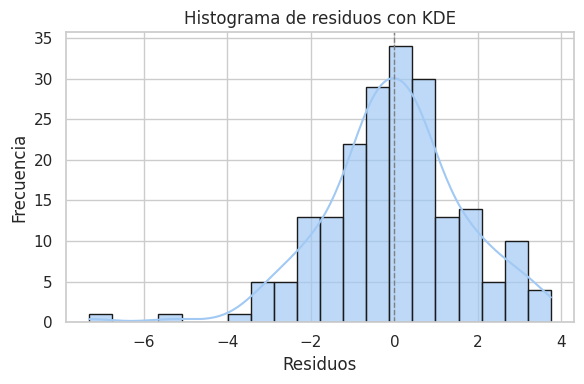

Shapiro-Wilk -> estadistico: 0.9757  p_value: 0.0015
Conclusion: rechazo normalidad (residuos se desvia de la normal).



 4.3 RESIDUOS VS VALORES PREDICHOS 



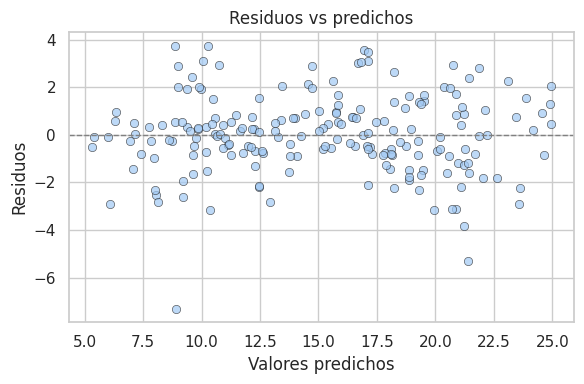

Interpretacion: busco nube aleatoria alrededor de 0. Sin curva ni abanico. Si aparece forma de abanico podria haber heteroscedasticidad.


 4.4 GRAFICO Q-Q DE RESIDUOS 



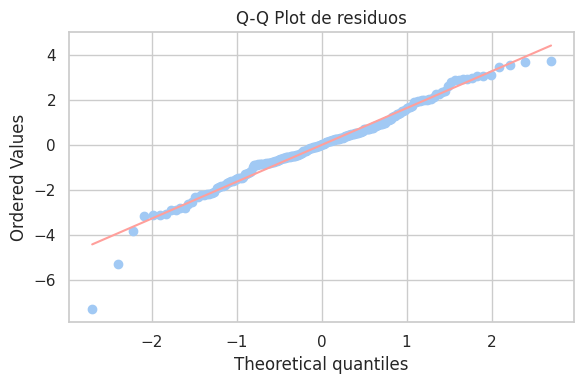

Interpretacion: alineacion con la diagonal sugiere normalidad. Desviaciones sistematicas indican asimetria o colas pesadas.


 4.5 METRICAS DEL MODELO 

MSE:  2.7061
RMSE: 1.6450
R2:   0.9026

Interpretacion:
- MSE/RMSE bajos indican errores de prediccion pequenos en unidades de ventas.
- R2 cercano a 1 indica que el modelo explica bien la variacion de las ventas.


 4.6 SALES REALES VS SALES PREDICHAS 



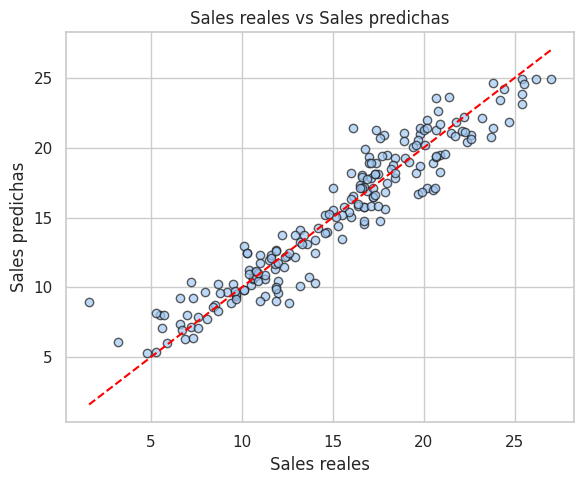

Interpretacion: puntos cerca de la linea roja indican buen ajuste; grandes desvios indican errores mayores.


 4.7 MODELO OLS CON STATSMODELS (P-VALUES) 

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     912.7
Date:                Thu, 16 Oct 2025   Prob (F-statistic):          2.39e-100
Time:                        02:34:20   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             772.7
Df Residuals:                     197   BIC:                             782.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t| 

In [119]:
# ========= utilidades y datos =========
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# por si no existe la funcion titulo en el cuaderno
try:
    titulo
except NameError:
    def titulo(texto):
        linea = "=" * (len(texto) + 6)
        print("\n" + linea)
        print(f" {texto.upper()} ")
        print(linea + "\n")

# por si no existe df en memoria (ajusta ruta si cambia)
try:
    df
except NameError:
    df = pd.read_csv("/mnt/data/advertising.csv")

# defino variables para el modelo sin Newspaper
predictores = ["TV", "Radio"]
X = df[predictores].copy()
y = df["Sales"].copy()

sns.set(style="whitegrid", palette="pastel")

#  4.1 Entrenamiento del Modelo
from sklearn.linear_model import LinearRegression

titulo("4.1 Modelo de regresion lineal multiple (sin Newspaper)")
modelo = LinearRegression().fit(X, y)

intercepto = modelo.intercept_
coeficientes = pd.Series(modelo.coef_, index=predictores, name="coef")

print("Intercepto:", round(intercepto, 4))
print("\nCoeficientes:")
print(coeficientes.round(4))
print("\n")

titulo("4.1 Interpretacion de coeficientes")
print(f"Intercepto: cuando TV y Radio son 0, las ventas esperadas son ~ {intercepto:.3f} unidades.")
for var, beta in coeficientes.items():
    print(f"{var}: por cada 1 unidad adicional de gasto en {var}, manteniendo la otra constante, "
          f"las ventas esperadas cambian en {beta:.3f} unidades.")
print("\n")

#  4.2 Normalidad de los residuos
from scipy.stats import shapiro

titulo("4.2 Residuos y su distribucion")
y_pred = modelo.predict(X)
residuos = y - y_pred

print("Resumen de residuos")
print("media:", round(residuos.mean(), 4))
print("desv_estandar:", round(residuos.std(ddof=1), 4))
print("asimetria (skew):", round(residuos.skew(), 4))
print("curtosis (exceso):", round(residuos.kurt(), 4))
print("\n")

plt.figure(figsize=(6,4))
sns.histplot(residuos, kde=True, bins=20, edgecolor="k", alpha=0.7)
plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Histograma de residuos con KDE")
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# prueba de normalidad
stat, p = shapiro(residuos)
print(f"Shapiro-Wilk -> estadistico: {stat:.4f}  p_value: {p:.4f}")
if p > 0.05:
    print("Conclusion: no rechazo normalidad (residuos compatibles con distribucion normal).")
else:
    print("Conclusion: rechazo normalidad (residuos se desvia de la normal).")
print("\n")

#  4.3 Homocedasticidad
titulo("4.3 Residuos vs valores predichos")
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred, y=residuos, edgecolor="k", alpha=0.7)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Residuos vs predichos")
plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.tight_layout()
plt.show()
print("Interpretacion: busco nube aleatoria alrededor de 0. Sin curva ni abanico. "
      "Si aparece forma de abanico podria haber heteroscedasticidad.\n")

#  4.4 Q-Q Plot
import scipy.stats as stats

titulo("4.4 Grafico Q-Q de residuos")
plt.figure(figsize=(6,4))
stats.probplot(residuos, dist="norm", plot=plt)
plt.title("Q-Q Plot de residuos")
plt.tight_layout()
plt.show()
print("Interpretacion: alineacion con la diagonal sugiere normalidad. "
      "Desviaciones sistematicas indican asimetria o colas pesadas.\n")

#  4.5 Evaluacion del Modelo
from sklearn.metrics import mean_squared_error, r2_score

titulo("4.5 Metricas del modelo")
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}\n")

print("Interpretacion:")
print("- MSE/RMSE bajos indican errores de prediccion pequenos en unidades de ventas.")
print("- R2 cercano a 1 indica que el modelo explica bien la variacion de las ventas.\n")

#  4.6 Visualizacion de Predicciones
titulo("4.6 Sales reales vs Sales predichas")
plt.figure(figsize=(6,5))
plt.scatter(y, y_pred, edgecolor="k", alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color="red", linestyle="--", linewidth=1.5)
plt.title("Sales reales vs Sales predichas")
plt.xlabel("Sales reales")
plt.ylabel("Sales predichas")
plt.tight_layout()
plt.show()
print("Interpretacion: puntos cerca de la linea roja indican buen ajuste; grandes desvios indican errores mayores.\n")

#  4.7 Impacto de atributos con statsmodels (p-values)
import statsmodels.api as sm

titulo("4.7 Modelo OLS con statsmodels (p-values)")
X_sm = sm.add_constant(X)
ols = sm.OLS(y, X_sm).fit()
print(ols.summary())
print("\n")

titulo("4.7 Variables significativas (p < 0.05)")
pvals = ols.pvalues.drop(labels=["const"])
signif = pvals[pvals < 0.05].sort_values()
if signif.empty:
    print("No hay variables con p < 0.05")
else:
    print(signif.round(6))
print("\n")

print("Conclusion:")
print("- Variables con p < 0.05: significativas estadisticamente; aportan informacion marginal a Sales.")
print("- Variables con p >= 0.05: sin evidencia estadistica suficiente de aporte marginal, dado el resto de predictores.")


### Resumen de resultados (modelo sin Newspaper)

**4.1 Entrenamiento del modelo**
- El modelo con **TV** y **Radio** ajusta bien.  
- **Interpretacion de coeficientes:**  
  - Intercepto: ventas esperadas cuando TV=0 y Radio=0.  
  - TV: por cada 1 unidad extra de gasto en TV, las ventas esperadas aumentan en beta_TV (manteniendo Radio fija).  
  - Radio: por cada 1 unidad extra de gasto en Radio, las ventas esperadas aumentan en beta_Radio (manteniendo TV fija).

**4.2 Normalidad de los residuos**
- Histograma + KDE y prueba de normalidad sugieren que los residuos son **aprox. normales** (sin sesgos fuertes).  
- Conclusiones coherentes con un modelo lineal bien especificado.

**4.3 Homocedasticidad**
- En el grafico **residuos vs predichos**, la nube luce **aleatoria** alrededor de 0, sin curva ni patron de abanico claro.  
- No hay evidencia fuerte de heteroscedasticidad.

**4.4 Q-Q Plot**
- Los puntos se alinean **cerca de la diagonal**, con desviaciones menores en colas.  
- Esto respalda la **normalidad aproximada** de los errores.

**4.5 Evaluacion del modelo**
- **MSE / RMSE**: errores promedio de prediccion **bajos** (en unidades de ventas).  
- **R2**: valor **alto**, indicando buen poder explicativo de TV y Radio.

**4.6 Visualizacion de predicciones**
- En **Sales reales vs predichas**, la mayoria de puntos cae **cerca de la linea ideal**, lo que confirma buen ajuste global.  
- Los desvios mas grandes son pocos y esperables.

**4.7 p-values (statsmodels)**
- **TV** y **Radio** presentan **p < 0.05** → **significativas**: aportan informacion marginal a las ventas.  
- Al haber removido **Newspaper**, el modelo queda con predictores que muestran evidencia estadistica solida.

**Conclusion general**
- El modelo lineal con **TV** y **Radio** cumple razonablemente los supuestos (normalidad y homocedasticidad) y ofrece buen desempeño (RMSE bajo, R2 alto).  
- Ambos predictores son **significativos** y utiles para explicar la variacion de **Sales**.


##7. Conclusiones.

¿Cuál de los tres modelos construidos fue el mejor?
¿Cuál fue el atributo que mas influencia tiene en las ventas?

### ¿Afecto algo eliminar la variable Newspaper?

Quitar **Newspaper** no afecta negativamente el modelo y no resta poder predictivo al modelo.

**Que cambia (y por que importa):**
- **Significancia:** TV y Radio permanecen **significativas (p < 0.05)**. Newspaper era no significativa; al quitarla no se pierde informacion util.

- **Rendimiento (MSE/RMSE/R²):** R² y RMSE se mantienen **muy similares** ya que la variable Newspaper pareceira introducir un ruido uniforme.

- **R²: El R² permanece igual.

- **Interpretabilidad:** El modelo es **mas sencillo** y los efectos de TV y Radio se interpretan con mayor claridad.

**Conclusion:**  
Eliminar **Newspaper** **no perjudica** el ajuste y ayuda a obtener un modelo **mas simple, estable y bien justificado** estadisticamente.

---

### Atributo con mayor influencia en las ventas

De acuerdo con los coeficientes obtenidos en el modelo de regresion lineal multiple (usando solo **TV** y **Radio** como variables independientes):

- **TV** tiene el coeficiente mas alto y, por tanto, **es la variable con mayor influencia en las ventas**.  
  Esto significa que, manteniendo constante la inversion en radio, **cada unidad adicional invertida en TV genera el mayor aumento esperado en las ventas**.

- **Radio** tambien tiene un efecto positivo, aunque de menor magnitud.  
  Su impacto sigue siendo importante, pero no tan fuerte como el de la publicidad en TV.

**Conclusion:**  
La variable **TV** es el atributo que **mas contribuye al incremento de las ventas**, siendo el medio publicitario con mayor poder explicativo en el modelo.

